In [1]:
%pip install gensim

   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/24.4 MB ? eta -:--:--
    --------------------------------------- 0.5/24.4 MB 419.7 kB/s eta 0:00:57
   - -------------------------------------- 0.8/24.4 MB 640.3 kB/s eta 0:00:37
   - -------------------------------------- 0.8/24.4 MB 640.3 kB/s eta 0:00:37
   - -------------------------------------- 0.8/24.4 MB 640.3 kB/s eta 0:00:37
   - -------------------------------------- 0.8/24.4 MB 640.3 kB/s eta 0:00:37
   - -------------------------------------- 1.0/24.4 MB 426.5 kB/s eta 0:00:55
   - -------------------------------

In [5]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)
from gensim.models import Word2Vec

sns.set_theme(style="whitegrid")

train = pd.read_csv("../data/processed/train.csv").dropna()
test = pd.read_csv("../data/processed/test.csv").dropna()
X_train, y_train = train["text_clean"], train["label"]
X_test, y_test = test["text_clean"], test["label"]
print(X_train.shape, X_test.shape)


def evaluer(nom, pipe, fichier_image, cv_folds=5):
    debut = time.time()
    pipe.fit(X_train, y_train)
    temps = time.time() - debut
    print(f"Temps d'entraînement : {temps:.2f} s\n")

    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rap = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"Accuracy  : {acc:.4f}")
    print(f"Précision : {prec:.4f}")
    print(f"Rappel    : {rap:.4f}")
    print(f"F1-score  : {f1:.4f}\n")
    print(classification_report(y_test, y_pred, target_names=["Non-spam", "Spam"], digits=4))

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    ConfusionMatrixDisplay(cm, display_labels=["Non-spam", "Spam"]).plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f"Matrice de confusion : {nom}")
    ax.grid(False)
    plt.tight_layout()
    plt.savefig(fichier_image, dpi=150)
    plt.show()
    tn, fp, fn, tp = cm.ravel()
    print(f"Faux positifs : {fp} | Faux négatifs : {fn}\n")

    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1")
    print("F1 par pli :", scores.round(4))
    print(f"F1 moyen : {scores.mean():.4f} (± {scores.std():.4f})")

    ligne = {"modèle": nom, "accuracy": acc, "précision": prec, "rappel": rap, "f1": f1,
             "faux_positifs": int(fp), "faux_négatifs": int(fn),
             "f1_validation_croisée": scores.mean(), "temps_entraînement_s": round(temps, 2)}
    chemin = "../data/processed/resultats.csv"
    res = pd.read_csv(chemin) if os.path.exists(chemin) else pd.DataFrame()
    if len(res) > 0:
        res = res[res["modèle"] != nom]
    res = pd.concat([res, pd.DataFrame([ligne])], ignore_index=True)
    res.to_csv(chemin, index=False)
    return pipe

(23812,) (5954,)


In [6]:
class MoyenneW2V(BaseEstimator, TransformerMixin):
    def __init__(self, vector_size=100, window=5, min_count=3, epochs=10):
        self.vector_size = vector_size
        self.window = window
        self.min_count = min_count
        self.epochs = epochs

    def fit(self, X, y=None):
        phrases = [t.split() for t in X]
        self.w2v_ = Word2Vec(sentences=phrases, vector_size=self.vector_size,
                             window=self.window, min_count=self.min_count,
                             workers=4, epochs=self.epochs, seed=42)
        return self

    def transform(self, X):
        wv = self.w2v_.wv
        out = np.zeros((len(X), self.vector_size))
        for i, t in enumerate(X):
            vecs = [wv[m] for m in t.split() if m in wv]
            if vecs:
                out[i] = np.mean(vecs, axis=0)
        return out

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Temps d'entraînement : 38.61 s

Accuracy  : 0.9807
Précision : 0.9738
Rappel    : 0.9853
F1-score  : 0.9795

              precision    recall  f1-score   support

    Non-spam     0.9869    0.9766    0.9817      3159
        Spam     0.9738    0.9853    0.9795      2795

    accuracy                         0.9807      5954
   macro avg     0.9804    0.9810    0.9806      5954
weighted avg     0.9808    0.9807    0.9807      5954



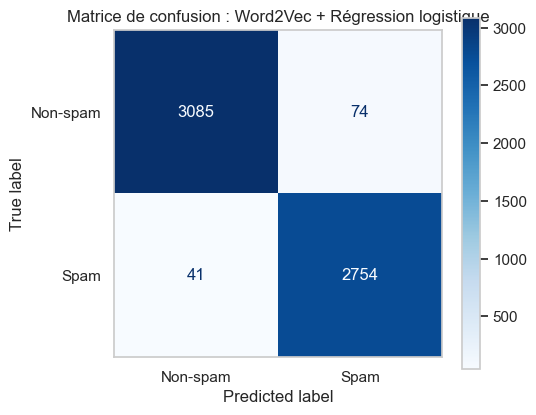

Faux positifs : 74 | Faux négatifs : 41



Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


F1 par pli : [0.9779 0.9783 0.9767 0.9771 0.9815]
F1 moyen : 0.9783 (± 0.0017)


In [7]:
pipe_w2v = Pipeline([
    ("w2v", MoyenneW2V(vector_size=100, window=5, min_count=3, epochs=10)),
    ("lr", LogisticRegression(max_iter=1000))
])
pipe_w2v = evaluer("Word2Vec + Régression logistique", pipe_w2v, "../images/07a_matrice_confusion_w2v.png")

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Temps d'entraînement : 37.78 s

Accuracy  : 0.9807
Précision : 0.9722
Rappel    : 0.9871
F1-score  : 0.9796

              precision    recall  f1-score   support

    Non-spam     0.9884    0.9750    0.9817      3159
        Spam     0.9722    0.9871    0.9796      2795

    accuracy                         0.9807      5954
   macro avg     0.9803    0.9811    0.9806      5954
weighted avg     0.9808    0.9807    0.9807      5954



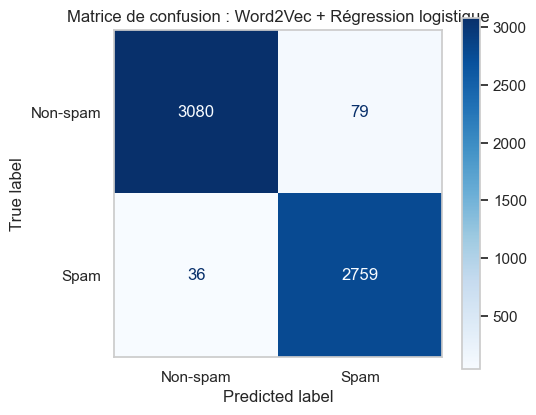

Faux positifs : 79 | Faux négatifs : 36



Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


F1 par pli : [0.9784 0.977  0.9776 0.9762 0.9804]
F1 moyen : 0.9779 (± 0.0014)


In [8]:
pipe_w2v = Pipeline([
    ("w2v", MoyenneW2V(vector_size=100, window=5, min_count=3, epochs=10)),
    ("lr", LogisticRegression(max_iter=1000))
])
pipe_w2v = evaluer("Word2Vec + Régression logistique", pipe_w2v, "../images/07a_matrice_confusion_w2v.png")

In [9]:
wv = pipe_w2v.named_steps["w2v"].w2v_.wv
for mot in ["viagra", "money", "enron", "meeting"]:
    if mot in wv:
        print(f"\nMots proches de « {mot} » :")
        print([m for m, s in wv.most_similar(mot, topn=8)])


Mots proches de « viagra » :
['cialis', 'levitra', 'xanax', 'valium', 'pill', 'codeine', 'sildenafil', 'softtabs']

Mots proches de « money » :
['funds', 'fund', 'sum', 'wisely', 'willing', 'payments', 'amount', 'invest']

Mots proches de « enron » :
['nombre', 'ene', 'dynegy', 'wednesday', 'friday', 'houston', 'employees', 'lay']

Mots proches de « meeting » :
['meetings', 'agenda', 'offsite', 'presentation', 'discussion', 'interviews', 'lunch', 'session']


In [10]:
pd.read_csv("../data/processed/resultats.csv").round(4)

,modèle,accuracy,précision,rappel,f1,faux_positifs,faux_négatifs,f1_validation_croisée,temps_entraînement_s
0,Naive Bayes + TF-IDF,0.9871,0.9885,0.9839,0.9862,32,45,0.9850,4.40
1,SVM linéaire + TF-IDF,0.9903,0.9837,0.9957,0.9897,46,12,0.9899,3.94
2,Random Forest + TF-IDF,0.9851,0.9771,0.9914,0.9842,65,24,0.9842,11.90
3,Word2Vec + Régression logistique,0.9807,0.9722,0.9871,0.9796,79,36,0.9779,37.78


In [11]:
import pandas as pd

res = pd.read_csv("../data/processed/resultats.csv")
bert = pd.read_csv("../data/processed/resultat_bert.csv")

# évite les doublons si la cellule est exécutée deux fois
res = res[~res["modèle"].str.startswith("DistilBERT")]
res = pd.concat([res, bert], ignore_index=True)
res.to_csv("../data/processed/resultats.csv", index=False)
res.round(4)

,modèle,accuracy,précision,rappel,f1,faux_positifs,faux_négatifs,f1_validation_croisée,temps_entraînement_s
0,Naive Bayes + TF-IDF,0.9871,0.9885,0.9839,0.9862,32,45,0.9850,4.40
1,SVM linéaire + TF-IDF,0.9903,0.9837,0.9957,0.9897,46,12,0.9899,3.94
2,Random Forest + TF-IDF,0.9851,0.9771,0.9914,0.9842,65,24,0.9842,11.90
3,Word2Vec + Régression logistique,0.9807,0.9722,0.9871,0.9796,79,36,0.9779,37.78
4,"DistilBERT (10000 emails, 2 époques)",0.9869,0.9860,0.9860,0.9860,39,39,NaN,205.80
